In [123]:
import pandas as pd
import geopandas as gpd

AUSTIN_COUNTIES = {
    "TRAVIS": '453', 
    "HAYS": '209', 
    "WILLIAMSON": '491',
    }

census = pd.read_csv("../processed_data/census_demographics.csv", dtype={'tract_code': str})
incidents = pd.read_csv("../processed_data/sf_incidents_with_tracts.csv")

# Needed for population density
census_gdf = gpd.read_file('../raw_data/tl_2023_48_tract.shp')
census_gdf = census_gdf[census_gdf['COUNTYFP'].isin(list(AUSTIN_COUNTIES.values()))]  # Filter for Austin Counties


census = census.merge(census_gdf[['TRACTCE', 'ALAND']], left_on='tract_code', right_on='TRACTCE')
census.rename(columns={'ALAND': 'land_area'}, inplace=True)
census.drop(columns=['TRACTCE'], inplace=True)
# Clean census data for median income values
census = census[census['median_income'] > 0]

# Assuming land_area is given in sq m.
census['population_density'] = census['population'] / census['land_area'] * 2.59e+6  # Convert to people per sq mile

<Axes: ylabel='Frequency'>

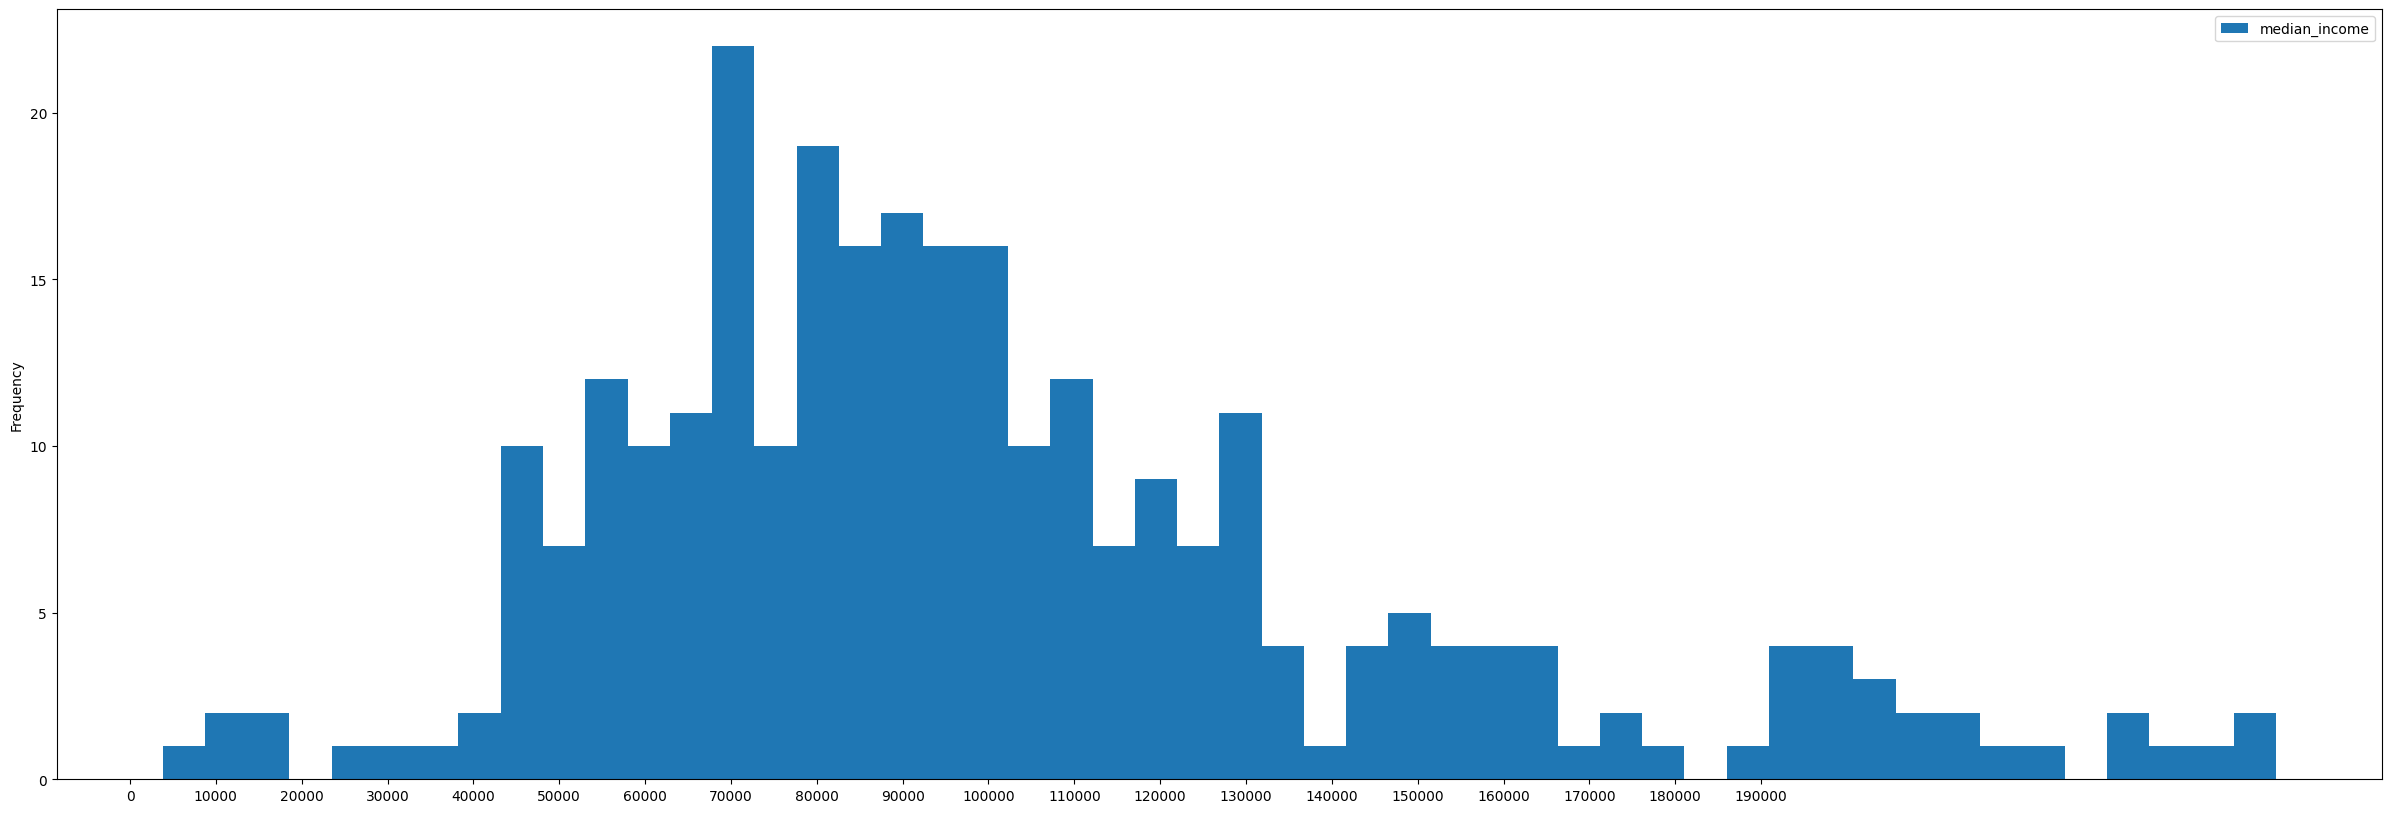

In [13]:
census[['tract_code','median_income']].plot(kind='hist', figsize=(30,10), bins=50, xticks=range(0, 200000, 10000))

In [12]:
census[['tract_code','median_income']].describe()

,median_income
count,286.000000
mean,101638.486014
std,46618.302276
min,3794.000000
25%,69964.750000
50%,92070.000000
75%,122420.750000
max,250001.000000


### Pick $80,000 as a cutoff point for census tracts. It's in between the two modes

In [124]:
census['high income'] = census['median_income'] > 80000
census['high income'] = census['high income'].astype(int)
census.head()

,tract_code,population,total_units,"1-unit, detached","1-unit, attached",total_units_age,Built 2010-2019,Built 2020 or later,Built 1939 or earlier,single_family_units,pct_single_family,pct_built_2010_plus,pct_built_pre1970,median_income,land_area,population_density,high income
0,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,3049819,3816.442877,1
1,000102,2155,1122,899,70,1122,34,39,9,969,86.363636,6.506239,0.802139,224688,5575522,1001.063219,1
2,000203,3020,1112,19,0,1112,414,5,11,19,1.708633,37.679856,0.989209,88968,1208518,6472.224659,1
3,000204,2593,1560,792,106,1560,60,8,435,898,57.564103,4.358974,27.884615,115375,1822932,3684.103411,1
4,000205,4549,2693,1008,154,2693,479,0,54,1162,43.148905,17.786855,2.005199,69314,1512162,7791.433722,0


In [125]:
census.columns

Index(['tract_code', 'population', 'total_units', '1-unit, detached',
       '1-unit, attached', 'total_units_age', 'Built 2010-2019',
       'Built 2020 or later', 'Built 1939 or earlier', 'single_family_units',
       'pct_single_family', 'pct_built_2010_plus', 'pct_built_pre1970',
       'median_income', 'land_area', 'population_density', 'high income'],
      dtype='str')

In [126]:
# Correlation with between pct_single_family and median_income is 0.6, which is the highest non-trivial correlation.
census[['population', 'total_units', 'Built 2010-2019', 'Built 2020 or later', 'Built 1939 or earlier',
        'pct_single_family', 'pct_built_2010_plus', 'pct_built_pre1970',
        'land_area', 'population_density', 'median_income']].corr()

,population,total_units,Built 2010-2019,Built 2020 or later,Built 1939 or earlier,pct_single_family,pct_built_2010_plus,pct_built_pre1970,land_area,population_density,median_income
population,1.000000,0.788079,0.570564,0.386221,-0.074491,0.149343,0.345472,-0.146757,0.180628,-0.002870,0.062174
total_units,0.788079,1.000000,0.630925,0.259278,0.093856,-0.142908,0.318539,-0.059811,0.029453,0.025487,-0.020021
Built 2010-2019,0.570564,0.630925,1.000000,0.491805,-0.009762,-0.039455,0.860868,-0.078700,0.196672,-0.062118,0.091334
Built 2020 or later,0.386221,0.259278,0.491805,1.000000,-0.058191,0.172077,0.556780,-0.071588,0.254927,-0.167942,0.089134
Built 1939 or earlier,-0.074491,0.093856,-0.009762,-0.058191,1.000000,-0.098618,-0.042735,0.918037,-0.101912,0.105022,-0.046928
pct_single_family,0.149343,-0.142908,-0.039455,0.172077,-0.098618,1.000000,0.009776,-0.086639,0.236676,-0.434084,0.626913
pct_built_2010_plus,0.345472,0.318539,0.860868,0.556780,-0.042735,0.009776,1.000000,-0.059334,0.224588,-0.054388,0.117871
pct_built_pre1970,-0.146757,-0.059811,-0.078700,-0.071588,0.918037,-0.086639,-0.059334,1.000000,-0.095854,0.113065,-0.066794
land_area,0.180628,0.029453,0.196672,0.254927,-0.101912,0.236676,0.224588,-0.095854,1.000000,-0.332474,0.126369
population_density,-0.002870,0.025487,-0.062118,-0.167942,0.105022,-0.434084,-0.054388,0.113065,-0.332474,1.000000,-0.383598


In [127]:
import ast

def parse_census_tracts(tract_str):
    """
    Parse census tract string from incidents file.
    Input: string like "['410']" or "['15.03']" or "['2.04', '2.03']"
    Returns: list of tract codes, or empty list if parsing fails
    """
    if pd.isna(tract_str) or tract_str == '':
        return []
    try:
        # Remove any whitespace
        tract_str = str(tract_str).strip()
        # Try to evaluate as Python literal
        tracts = ast.literal_eval(tract_str)
        if isinstance(tracts, str):
            return [tracts]
        elif isinstance(tracts, list):
            return [str(t) for t in tracts]
        else:
            return []
    except:
        return []
    
def explode_incidents_by_tract(incidents_df):
     ### Since we're exploding by tract, we need to make sure to average out the census demographics in the case of boundaries.
    """
    Create one row per incident-tract combination.
    For incidents in multiple tracts, duplicate the row.
    """
    print("\nExploding incidents by tract...")
    
    # Create list of incident-tract pairs
    pairs = []
    for idx, row in incidents_df.iterrows():
        tracts = row['tract_list']
        if len(tracts) > 0:
            for tract in tracts:
                pairs.append({**row.to_dict(), 'tract_code': tract})
    
    # Convert to dataframe
    exploded = pd.DataFrame(pairs)
    
    return exploded

In [128]:
incidents['tract_list'] = incidents['tract_codes'].apply(parse_census_tracts)
exp_df = explode_incidents_by_tract(incidents)


Exploding incidents by tract...


In [129]:
incidents[incidents['tract_list'].apply(lambda x: len(x) > 1)]

,incident_number,calendaryear,month,incdate,problem,responsearea,council_district,location,longitude,latitude,census_tracts,tract_codes,tract_list
34,22003662,2022,Jan,01/07/2022 12:00:00 AM,BOXL- Structure Fire,00-0303,9,"(-97.741431,30.304425)",-97.741431,30.304425,"['2.04', '2.03']","['000204', '000203']","[000204, 000203]"
54,22007278,2022,Jan,01/15/2022 12:00:00 AM,BOX -Structure Fire,00-2203,3,"(-97.717205,30.237520)",-97.717205,30.237520,"['23.24', '23.26']","['002324', '002326']","[002324, 002326]"
69,22009976,2022,Jan,01/20/2022 12:00:00 AM,BOX -Structure Fire,05-4604,-,"(-97.853297,30.178153)",-97.853297,30.178153,"['313', '319']","['031300', '031900']","[031300, 031900]"
85,22011294,2022,Jan,01/23/2022 12:00:00 AM,BOX -Structure Fire,00-1706,3,"(-97.765313,30.233119)",-97.765313,30.233119,"['13.08', '13.07']","['001308', '001307']","[001308, 001307]"
100,22012115,2022,Jan,01/24/2022 12:00:00 AM,BOX -Structure Fire,00-0301,9,"(-97.743918,30.295922)",-97.743918,30.295922,"['6.06', '6.05', '2.04']","['000606', '000605', '000204']","[000606, 000605, 000204]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2909,24143162,2024,Oct,10/13/2024 12:00:00 AM,BOXMID -MIDRISE Structure Fire,00-2206,3,"(-97.706991,30.220168)",-97.706991,30.220168,"['23.20', '23.14']","['002320', '002314']","[002320, 002314]"
2955,24150929,2024,Oct,10/28/2024 12:00:00 AM,BOXL- Structure Fire,04-3305,10,"(-97.783577,30.399873)",-97.783577,30.399873,"['305', '326']","['030500', '032600']","[030500, 032600]"
3042,24165865,2024,Nov,11/26/2024 12:00:00 AM,BOXS - Still Box Alarm,00-1706,3,"(-97.763028,30.236734)",-97.763028,30.236734,"['13.08', '13.07']","['001308', '001307']","[001308, 001307]"
3052,24166732,2024,Nov,11/28/2024 12:00:00 AM,BOX -Structure Fire,00-0201,9,"(-97.741991,30.282642)",-97.741991,30.282642,"['6.08', '6.01']","['000608', '000601']","[000608, 000601]"


In [130]:
agg_inc = exp_df.groupby('tract_code').agg({
    'incident_number': 'count',
})
agg_inc.rename(columns={'incident_number': 'incident_count'}, inplace=True)
agg_inc.head()

,incident_count
tract_code,
000101,22
000102,10
000203,9
000204,16
000205,13


In [131]:
df = census.merge(agg_inc, left_on='tract_code', right_on='tract_code', how='left')

In [132]:
df['incident_per_1000_pop'] = df['incident_count'] / df['population'] * 1000

In [133]:
df.columns

Index(['tract_code', 'population', 'total_units', '1-unit, detached',
       '1-unit, attached', 'total_units_age', 'Built 2010-2019',
       'Built 2020 or later', 'Built 1939 or earlier', 'single_family_units',
       'pct_single_family', 'pct_built_2010_plus', 'pct_built_pre1970',
       'median_income', 'land_area', 'population_density', 'high income',
       'incident_count', 'incident_per_1000_pop'],
      dtype='str')

In [134]:
df.head()

,tract_code,population,total_units,"1-unit, detached","1-unit, attached",total_units_age,Built 2010-2019,Built 2020 or later,Built 1939 or earlier,single_family_units,pct_single_family,pct_built_2010_plus,pct_built_pre1970,median_income,land_area,population_density,high income,incident_count,incident_per_1000_pop
0,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,3049819,3816.442877,1,22.0,4.895416
1,000102,2155,1122,899,70,1122,34,39,9,969,86.363636,6.506239,0.802139,224688,5575522,1001.063219,1,10.0,4.640371
2,000203,3020,1112,19,0,1112,414,5,11,19,1.708633,37.679856,0.989209,88968,1208518,6472.224659,1,9.0,2.980132
3,000204,2593,1560,792,106,1560,60,8,435,898,57.564103,4.358974,27.884615,115375,1822932,3684.103411,1,16.0,6.170459
4,000205,4549,2693,1008,154,2693,479,0,54,1162,43.148905,17.786855,2.005199,69314,1512162,7791.433722,0,13.0,2.857771


<Axes: xlabel='population_density', ylabel='incident_per_1000_pop'>

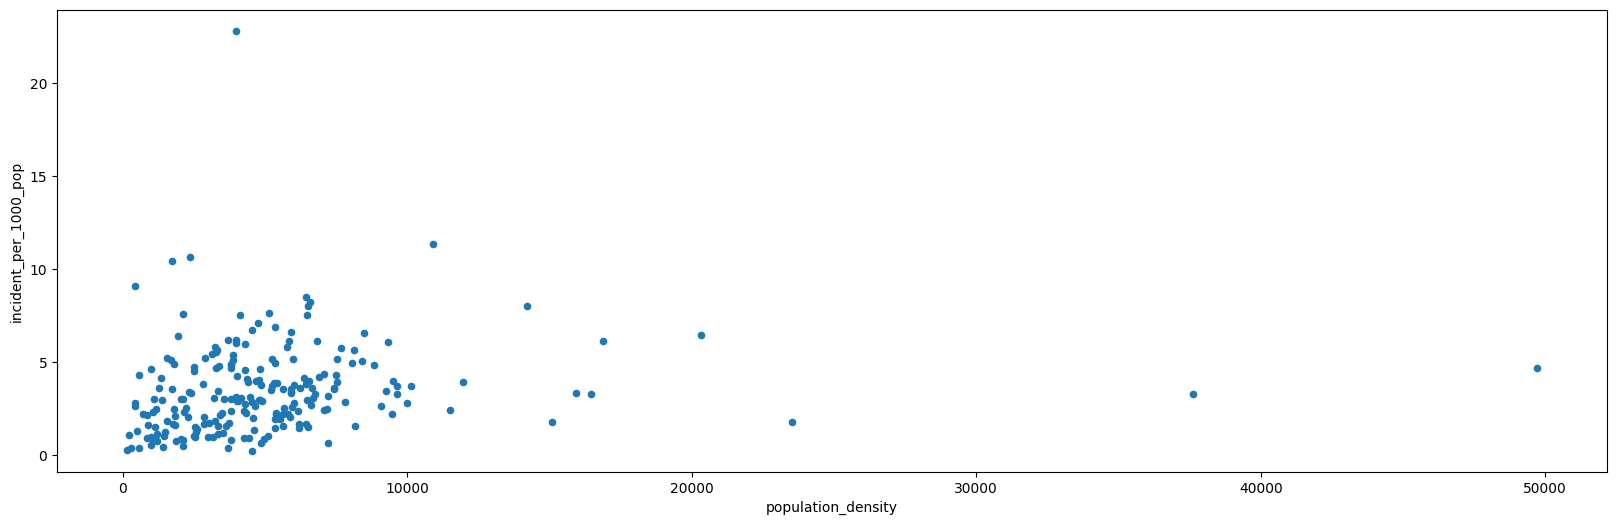

In [135]:
df.plot.scatter(x='population_density', y='incident_per_1000_pop', figsize=(20,6))

<Axes: xlabel='population_density', ylabel='incident_per_1000_pop'>

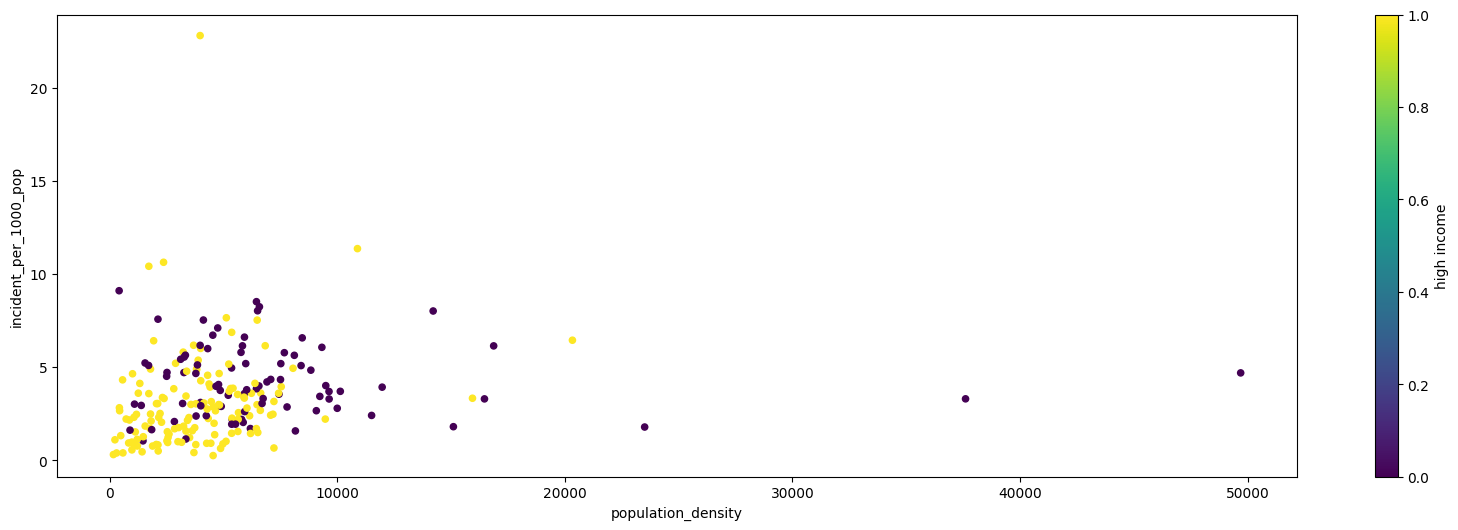

In [136]:
# color by median income
df.plot.scatter(x='population_density', y='incident_per_1000_pop', figsize=(20,6), c='high income', colormap='viridis')

In [137]:
# Do a linear regression of population density vs incident_per_1000_pop, controlling for median income
import statsmodels.api as sm
X = df[['population_density', 'high income']]
# X = sm.add_constant(X)
y = df['incident_per_1000_pop']
model = sm.OLS(y, X).fit()
print(model.summary())

                                  OLS Regression Results                                  
Dep. Variable:     incident_per_1000_pop   R-squared (uncentered):                     nan
Model:                               OLS   Adj. R-squared (uncentered):                nan
Method:                    Least Squares   F-statistic:                                nan
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):                         nan
Time:                           22:24:54   Log-Likelihood:                             nan
No. Observations:                    286   AIC:                                        nan
Df Residuals:                        284   BIC:                                        nan
Df Model:                              2                                                  
Covariance Type:               nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---

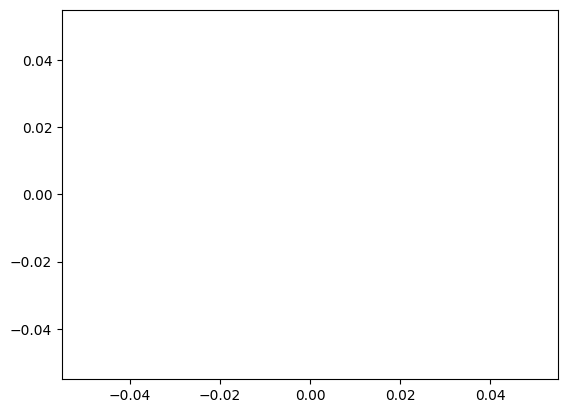

In [ ]:
# Plot the regression line
import numpy as np
import matplotlib.pyplot as plt


# df['predicted_incidents'] = model.predict(X)
# df.plot.scatter(x='population_density', y='incident_per_1000_pop', figsize=(20,6), c='high income', colormap='viridis')
plt.plot(df['population_density'], df['predicted_incidents'], color='red')
plt

In [90]:
agg_inc.head()

,incident_count
tract_code,
000101,22
000102,10
000203,9
000204,16
000205,13


In [91]:
census.head()

,tract_code,population,total_units,"1-unit, detached","1-unit, attached",total_units_age,Built 2010-2019,Built 2020 or later,Built 1939 or earlier,single_family_units,pct_single_family,pct_built_2010_plus,pct_built_pre1970,median_income,land_area,population_density,high income
0,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,233160700,0.000019,1
1,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,1967624,0.002284,1
2,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,227814472,0.000020,1
3,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,3049819,0.001474,1
4,000101,4494,2475,1424,175,2475,295,70,70,1599,64.606061,14.747475,2.828283,131713,140513115,0.000032,1
